In [28]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report

In [29]:
df = pd.read_csv("realistic_skincare_reviews_12k.csv")

print(df.head())
print(df.shape)

   review_id           product_name skin_type  rating  \
0          1  Aloe Vera Moisturizer       Dry       4   
1          2  Aloe Vera Moisturizer    Normal       4   
2          3   Hydrating Face Cream       Dry       4   
3          4        Sunscreen SPF50    Normal       2   
4          5   Anti-Aging Eye Cream       Dry       4   

                                         review_text review_date sentiment  
0  I have been using this Aloe Vera Moisturizer f...  2021-07-12  Positive  
1  This Aloe Vera Moisturizer feels lightweight a...  2023-05-07   Neutral  
2  After regular use this Hydrating Face Cream im...  2021-09-11  Positive  
3  My skin reacted badly after trying this Sunscr...  2021-04-06  Positive  
4  This Anti-Aging Eye Cream works well for my Dr...  2024-02-22  Positive  
(12000, 7)


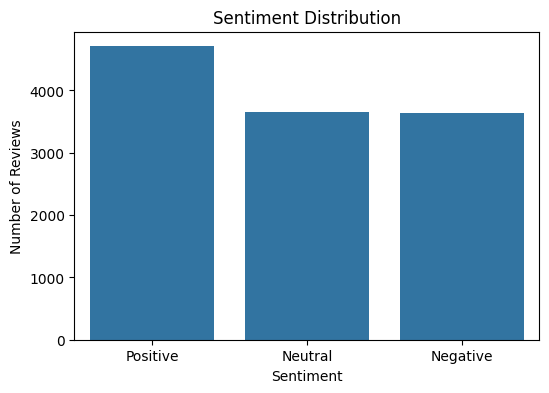

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

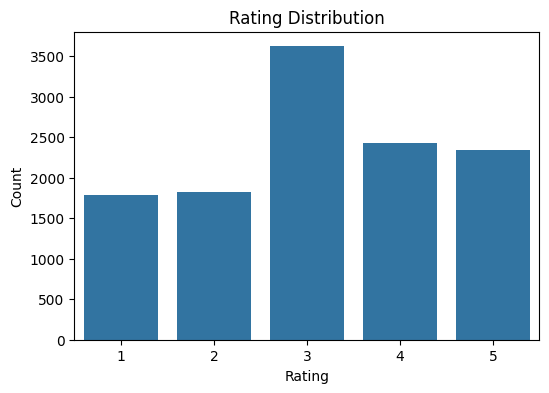

In [31]:
plt.figure(figsize=(6,4))
sns.countplot(x='rating', data=df)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

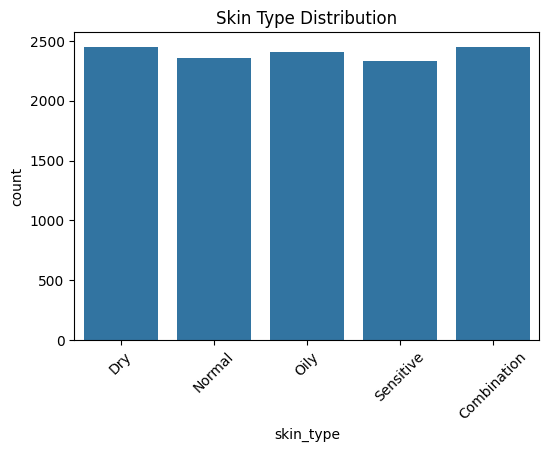

In [32]:
plt.figure(figsize=(6,4))
sns.countplot(x='skin_type', data=df)

plt.title("Skin Type Distribution")
plt.xticks(rotation=45)

plt.show()

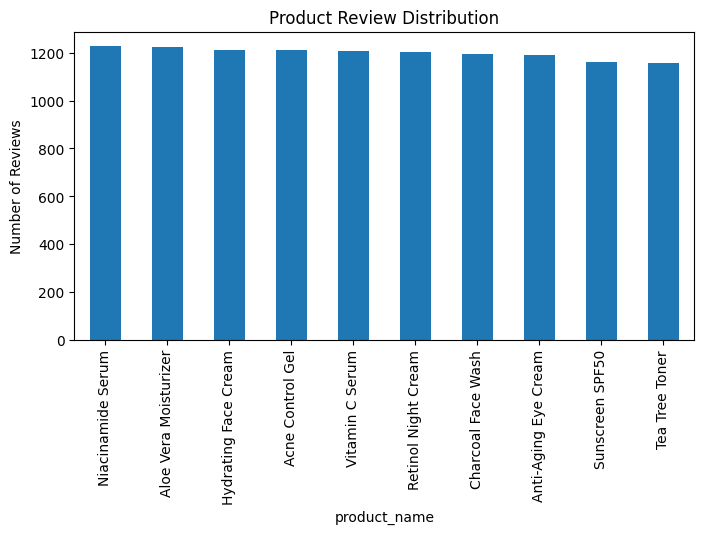

In [33]:
plt.figure(figsize=(8,4))
df['product_name'].value_counts().plot(kind='bar')

plt.title("Product Review Distribution")
plt.ylabel("Number of Reviews")

plt.show()

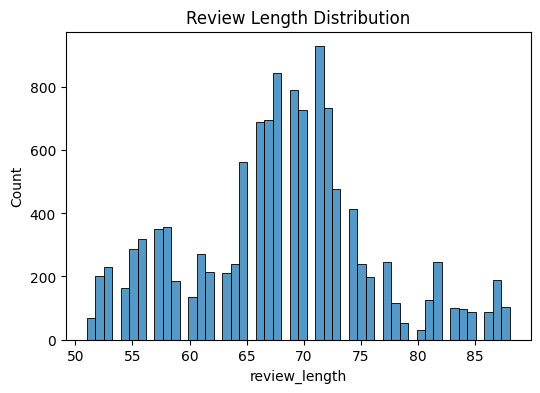

In [34]:
df['review_length'] = df['review_text'].apply(len)

plt.figure(figsize=(6,4))
sns.histplot(df['review_length'], bins=50)

plt.title("Review Length Distribution")

plt.show()

In [35]:
X = df['review_text']
y = df['sentiment']

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', max_features=3000)

X_vectorized = vectorizer.fit_transform(X)

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [40]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.94125


In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.94125


In [42]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.94125


In [43]:
from sklearn.metrics import classification_report

print("Naive Bayes Report")
print(classification_report(y_test, y_pred))

print("Logistic Regression Report")
print(classification_report(y_test, y_pred_lr))

print("Random Forest Report")
print(classification_report(y_test, y_pred_rf))

Naive Bayes Report
              precision    recall  f1-score   support

    Negative       0.93      0.94      0.94       687
     Neutral       0.95      0.92      0.94       762
    Positive       0.94      0.96      0.95       951

    accuracy                           0.94      2400
   macro avg       0.94      0.94      0.94      2400
weighted avg       0.94      0.94      0.94      2400

Logistic Regression Report
              precision    recall  f1-score   support

    Negative       0.93      0.94      0.94       687
     Neutral       0.95      0.92      0.94       762
    Positive       0.94      0.96      0.95       951

    accuracy                           0.94      2400
   macro avg       0.94      0.94      0.94      2400
weighted avg       0.94      0.94      0.94      2400

Random Forest Report
              precision    recall  f1-score   support

    Negative       0.93      0.94      0.94       687
     Neutral       0.95      0.92      0.94       762
    Posi

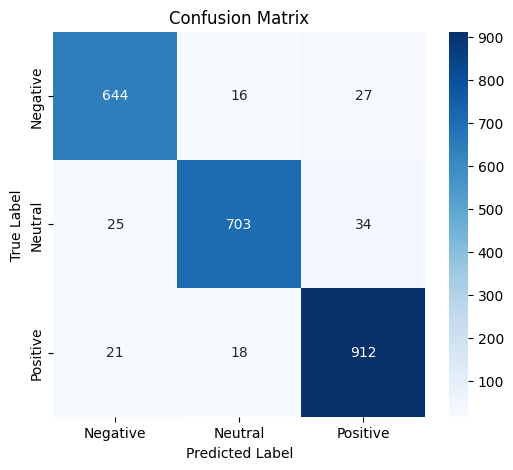

In [44]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Neutral','Positive'],
            yticklabels=['Negative','Neutral','Positive'])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [17]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=['Negative','Neutral','Positive'])

In [18]:
y_score = model.predict_proba(X_test)

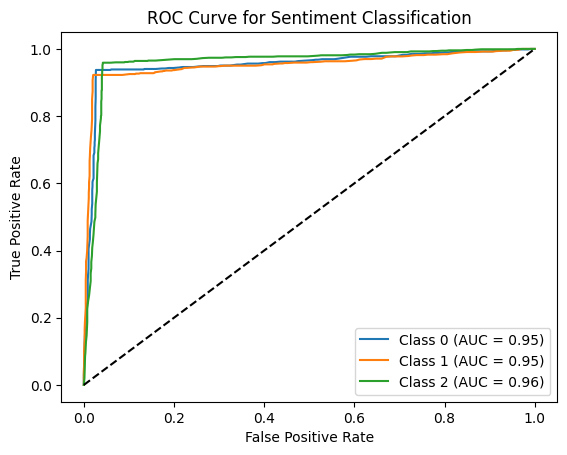

In [19]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(3):
    
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()

for i in range(3):
    
    plt.plot(fpr[i], tpr[i],
             label="Class {} (AUC = {:.2f})".format(i, roc_auc[i]))

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Sentiment Classification")

plt.legend()
plt.show()

In [20]:
from sklearn.model_selection import validation_curve
import numpy as np

param_range = np.logspace(-3,1,5)

train_scores, test_scores = validation_curve(
    
    MultinomialNB(),
    X_vectorized,
    y,
    param_name="alpha",
    param_range=param_range,
    cv=5,
    scoring="accuracy"
)

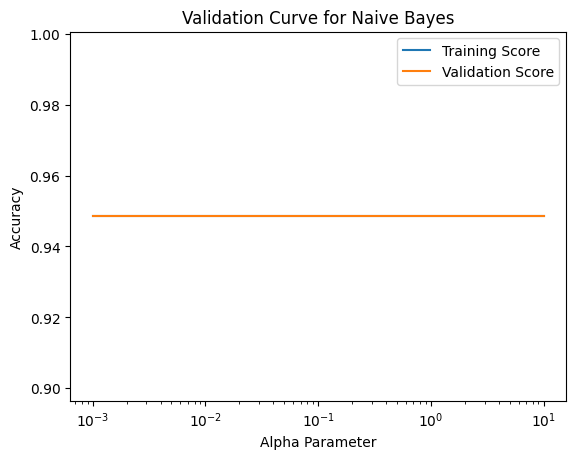

In [21]:
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(param_range, train_mean, label="Training Score")
plt.plot(param_range, test_mean, label="Validation Score")

plt.xscale("log")

plt.xlabel("Alpha Parameter")
plt.ylabel("Accuracy")
plt.title("Validation Curve for Naive Bayes")

plt.legend()
plt.show()

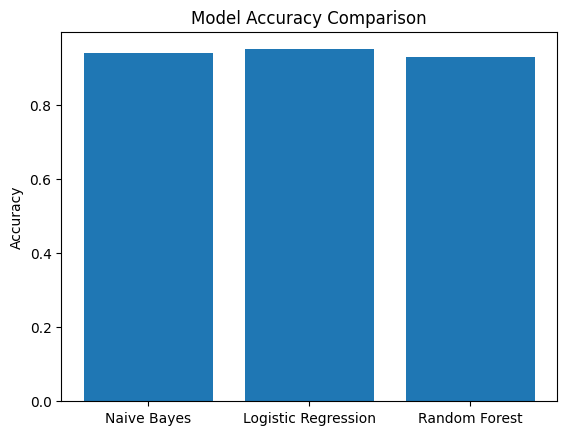

In [22]:
models = ['Naive Bayes','Logistic Regression','Random Forest']
accuracy = [0.94,0.95,0.93]

plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

In [23]:
import pickle

pickle.dump(model, open("sentiment_model.pkl", "wb"))

In [24]:
pickle.dump(vectorizer, open("tfidf_vectorizer.pkl", "wb"))

In [25]:
import pickle

model = pickle.load(open("sentiment_model.pkl", "rb"))
vectorizer = pickle.load(open("tfidf_vectorizer.pkl", "rb"))

In [26]:
sample = ["This moisturizer works really well for my skin"]

sample_vec = vectorizer.transform(sample)

prediction = model.predict(sample_vec)

print("Predicted Sentiment:", prediction[0])

Predicted Sentiment: Positive
